# Imports

In [1]:
import sys, os, tempfile, shutil, subprocess, json, requests
from pathlib import Path
import pandas as pd
from tqdm.notebook import tqdm
import molviewspec as mvs

In [2]:
sys.path.append("..")

In [3]:
from predict import \
Cif, Pocket, view_pockets

/home/fnerin/miniconda3/envs/allopockets/lib/python3.11/site-packages/autogluon/common/utils/utils.py:78: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/fnerin/miniconda3/envs/allopockets/lib/python3.11/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [4]:
outdir = "cofolding"
os.makedirs(outdir, exist_ok=True)

## Data

In [5]:
extra_holos_featuresd = pd.read_pickle("../training_data/7.Extra_set/features.pkl")
extra_holos_featuresd

{'7gqu':     Residues                                                          \
          pdb label_entity_id label_asym_id label_seq_id auth_asym_id   
 0       7gqu               1             A           12            A   
 1       7gqu               1             A           13            A   
 2       7gqu               1             A           14            A   
 3       7gqu               1             A           15            A   
 4       7gqu               1             A           16            A   
 ..       ...             ...           ...          ...          ...   
 414     7gqu               1             A          426            A   
 415     7gqu               1             A          427            A   
 416     7gqu               1             A          428            A   
 417     7gqu               1             A          429            A   
 418     7gqu               1             A          430            A   
 
                                   Label 

In [6]:
extra_holos_sites = {k: v for k, v in pd.read_pickle("../training_data/7.Extra_set/news_sites.pkl").items() if k in extra_holos_featuresd}
extra_holos_sites

{'7gqu': [{'mod':      label_comp_id label_asym_id label_entity_id label_seq_id  \
   3420           X1L             D               4            .   
   
        pdbx_PDB_ins_code auth_seq_id auth_comp_id auth_asym_id  \
   3420                 ?        1002          X1L            A   
   
        pdbx_PDB_model_num pdbx_label_index pdbx_sifts_xref_db_name  \
   3420                  1             1002                       ?   
   
        pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_num pdbx_sifts_xref_db_res  
   3420                      ?                      ?                      ?  ,
   'site':    label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
   0            VAL             A               1           55                 ?   
   1            MET             A               1           56                 ?   
   2            ALA             A               1           57                 ?   
   3            THR             A               1         

In [7]:
apos = pd.read_pickle(f"pdb_ensemble/apos.pkl")
overlaps = pd.read_pickle(f"pdb_ensemble/predictions.pkl")
origapos = pd.read_pickle("../models/other_tools_apos/models_lenient_labelling.pkl")["model5"]

#### 8jp0 - 8sgi

In [8]:
overlaps["8jp0"].pop("8sgi")

{'pocket': 'pocket2',
 'site_in_pocket': 0.53125,
 'pocket_in_site': 0.3695652173913043,
 'site':    label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
 0            GLU             A               1          132                 ?   
 1            THR             A               1          133                 ?   
 2            VAL             A               1          134                 ?   
 3            SER             A               1          135                 ?   
 4            LEU             A               1          137                 ?   
 5            THR             A               1          138                 ?   
 6            ALA             A               1          141                 ?   
 7            HIS             A               1          200                 ?   
 8            VAL             A               1          203                 ?   
 9            VAL             A               1          206                 ?   
 

# Sequences

In [9]:
seqsf = f"{outdir}/seqs.pkl"

if os.path.isfile(seqsf):
    seqs = pd.read_pickle(seqsf)
else:
    seqs = {}

In [23]:
for holo in tqdm(extra_holos_featuresd):
    print(holo)
    origcif = Cif(f"{holo}", f"../training_data/7.Extra_set/origcifs/{holo}_updated.cif.gz")
    site = extra_holos_sites[holo][0]
    wholeseq = (
        pd.DataFrame(origcif.cif.data["_entity_poly"])
        .query(f"""entity_id == '{ site["site"].label_entity_id.unique().item() }'""")
        .pdbx_seq_one_letter_code_can.item().replace("\n", "")
    )
    seqmin, seqmax = (
        origcif.residues
        .query(f"""label_asym_id == '{ site["site"].label_asym_id.unique().item() }'""")
        .label_seq_id
        .loc[lambda x: x != "."]
        .iloc[[0, -1]].astype(int).to_list()
    )
    seq = wholeseq[seqmin-1:seqmax]
    print(seq)
    site_ids = site["site"].label_seq_id.astype(int) - seqmin
    print("\t", "".join(site["site"]["pdbx_sifts_xref_db_res"]))
    print("\t", "".join(
        map(
            str,
            pd.DataFrame(list(seq)).iloc[list(site_ids)][0]
        )
    ))

    seqs[holo] = {
        "site": site,
        "seq": seq,
        "seqmin": seqmin,
        "seqmax": seqmax,
        # Getting residues from the 0-indexed `seq` should retrieve the correct site. For the `label_seq_id` of the generated PDBs, 1 must be added to each number
        "site_seqids": tuple(site_ids + 1),
        "ccd": site["mod"]["label_comp_id"].item()
    }
    
pd.to_pickle(seqs, seqsf)

  0%|          | 0/9 [00:00<?, ?it/s]

7gqu
FLWPAPNEEQVTCLKMYFGHSSFKPVQWKVIHSVLEERRDNVAVMATGYGKSLCFQYPPVYVGKIGLVISPLISLMEDQVLQLKMSNIPACFLGSAQSENVLTDIKLGKYRIVYVTPEYCSGNMGLLQQLEADIGITLIAVDEAHCISEWGHDFRDSFRKLGSLKTALPMVPIVALTATASSSIREDIVRCLNLRNPQITCTGFDRPNLYLEVRRKTGNILQDLQPFLVKTSSHWEFEGPTIIYCPSRKMTQQVTGELRKLNLSCGTYHAGMSFSTRKDIHHRFVRDEIQCVIATIAFGMGINKADIRQVIHYGAPKDMESYYQEIGRAGRDGLQSSCHVLWAPADINLNRHLLTEIRNEKFRLYKLKMMAKMEKYLHSSRCRRQIILSHFEDKQVQKASLGIMGTEKCCDNCRSRLDH
	 VMATATASRITCTGDMESYQYMKIHFEDK
	 VMATATASRITCTGDMESYQYMKIHFEDK
7yg5
NIVRKYAKKLIDWPPFEYMILATIIANCIVLALEQHLPEDDKTPMSRRLEKTEPYFIGIFCFEAGIKIVALGFIFHKGSYLRNGWNVMDFIVVLSGILATAGTHFNTHVDLRTLRAVRVLRPLKLVSGIPSLQIVLKSIMKAMVPLLQIGLLLFFAILMFAIIGLEFYSGKLHRACFMNNSGILEGFDPPHPCGVQGCPAGYECKDWIGPNDGITQFDNILFAVLTVFQCITMEGWTTVLYNTNDALGATWNWLYFIPLIIIGSFFVLNLVLGVLSGEFAKERERVENRRAFMKLRRQQQIERELNGYRAWIDKAEEVMLAEENKNAGTSALEVLRRATIKRSRTEAMTRDSSDEHCVDISSVGTPLARASIKSAKVDGVSYFRHKERLLRISIRHMVKSQVFYWIVLSLVALNTACVAIVHHNQPQWLTHLLYYAEFLFLGLFLLEMSLKMYGMGPRLYFHSSFNCFDFGVTVGSIFEVVWAIFRPGTSFGISVLRALRLLRIFK

{'7gqu': {'site': {'mod':      label_comp_id label_asym_id label_entity_id label_seq_id  \
   3420           X1L             D               4            .   
   
        pdbx_PDB_ins_code auth_seq_id auth_comp_id auth_asym_id  \
   3420                 ?        1002          X1L            A   
   
        pdbx_PDB_model_num pdbx_label_index pdbx_sifts_xref_db_name  \
   3420                  1             1002                       ?   
   
        pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_num pdbx_sifts_xref_db_res  
   3420                      ?                      ?                      ?  ,
   'site':    label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
   0            VAL             A               1           55                 ?   
   1            MET             A               1           56                 ?   
   2            ALA             A               1           57                 ?   
   3            THR             A               1 

In [10]:
seqs

{'7gqu': {'site': {'mod':      label_comp_id label_asym_id label_entity_id label_seq_id  \
   3420           X1L             D               4            .   
   
        pdbx_PDB_ins_code auth_seq_id auth_comp_id auth_asym_id  \
   3420                 ?        1002          X1L            A   
   
        pdbx_PDB_model_num pdbx_label_index pdbx_sifts_xref_db_name  \
   3420                  1             1002                       ?   
   
        pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_num pdbx_sifts_xref_db_res  
   3420                      ?                      ?                      ?  ,
   'site':    label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
   0            VAL             A               1           55                 ?   
   1            MET             A               1           56                 ?   
   2            ALA             A               1           57                 ?   
   3            THR             A               1 

In [10]:
seqsdff = f"{outdir}/seqsdf.pkl"

if os.path.isfile(seqsdff):
    seqsdf = pd.read_pickle(seqsdff)
else:
    for holo, holod in seqs.items():
        j = requests.get(f"https://data.rcsb.org/rest/v1/core/chemcomp/{holod['ccd']}").json()
        seqs[holo]["smiles"] = (
            j.get("rcsb_chem_comp_descriptor",{}).get("smiles")
            or j.get("rcsb_chem_comp_descriptor",{}).get("smiles_stereo")
            or next((x["descriptor"] for x in j.get("pdbx_chem_comp_descriptor",[])
                       if x.get("type","").startswith("SMILES")), "SMILES not found")
        )
    seqsdf = pd.DataFrame({k: {k1: v1 for k1, v1 in v.items() if k1 != "site"} for k, v in seqs.items()}).T
    pd.to_pickle(seqsdf, seqsdff)

seqsdf

,seq,seqmin,seqmax,site_seqids,ccd,smiles
7gqu,FLWPAPNEEQVTCLKMYFGHSSFKPVQWKVIHSVLEERRDNVAVMA...,12,430,"(44, 45, 46, 177, 178, 179, 180, 181, 185, 199...",X1L,CC(c1ncc(c(n1)Oc2ccccc2)C(=O)NC(CCS(=O)(=O)C)C...
7yg5,NIVRKYAKKLIDWPPFEYMILATIIANCIVLALEQHLPEDDKTPMS...,76,1871,"(134, 135, 138, 139, 142, 278, 279, 282, 283, ...",TOR,CC1(OC2COC3(C(C2O1)OC(O3)(C)C)COS(=O)(=O)N)C
8aq6,MVFTLEDFVGDWRQTAGYNLDQVLEQGGVSSLFQNLGVSVTPIQRI...,11,181,"(11, 12, 13, 43, 45, 57, 59, 61, 83, 84, 85, 9...",NT0,c1ccc(cc1)Cc2c(ncc(n2)c3ccccc3)NC(=O)Cc4ccco4
8f4s,SSQAWQPGVAMPNLYKMQRMLLEKCDLQNYGDSATLPKGIMMNVAK...,4,301,"(68, 70, 71, 96, 98, 111, 113, 114, 115, 116, ...",XDU,c1cc(c(cc1Cl)Cl)C=Cc2cc(nc(n2)O)C(F)(F)F
8jp0,GSYYCKKGVILPIWEPQDPSFGDKIARATVYFVAMVYMFLGVSIIA...,51,937,"(82, 83, 84, 85, 87, 88, 91, 150, 153, 156, 15...",EKY,CCOc1ccc(c(c1)N)Oc2ccc(cc2)OCc3cc(ccc3F)F
8qni,QAAADRRTVEKTWKLMDKVVRLCQNPKLQLKNSPPYILDILPDTYQ...,5,387,"(104, 107, 108, 109, 111, 112, 115, 181, 182, ...",W7R,CC1CN(CCO1)Cc2ccccc2C(=O)NC3C(=O)Nc4cnccc4C(=N...
8uk6,PERSMFSEGFLGDLHKPGEEPQMYPELLEEHKKFICDKVYTRFPPE...,233,812,"(49, 50, 51, 52, 55, 280, 281, 282, 283, 284, ...",WVK,c1cc(sc1)C=CC(=O)Nc2ncccn2
8v81,RSPLEKASVVSKLFFSWTRPILRKGYRQRLELSDIYQIPSVDSADN...,1,1438,"(90, 93, 308, 309, 342, 343, 345, 346, 351, 91...",WG5,c1cc(cc(c1)N2C(=O)C(=Cc3ccc(cc3)C(=O)O)SC2=S)C...
9dnm,TRVFKKASPNGKLTVYLGKRDFVDHIDLVDPVDGVVLVDPEYLKER...,6,492,"(129, 344, 345, 346, 347, 348, 379, 380, 381, ...",ODN,CC1C2CCC3C45COC(C3(C2O)C1=O)(C(C4C(CCC5O)(C)C)O)O


## A3Ms

In [11]:
msadir = f"{outdir}/a3ms"
os.makedirs(msadir, exist_ok=True)

In [33]:
# shutil.copy("bioemu_8uk6/test.a3m", f"{msadir}/8uk6.a3m")

'cofolding/a3ms/8uk6.a3m'

In [35]:
mmseqs = "/home/fnerin/miniconda3/envs/mmseqs/bin/mmseqs"
db = "/data/fnerin/uniref30_2302/uniref30_2302_db"

for holo, holorow in tqdm(tuple(seqsdf.iterrows())):
    msaf = f"{msadir}/{holo}.a3m"
    if os.path.isfile(msaf):
        continue
    seq = holorow["seq"]
    with tempfile.TemporaryDirectory() as tmpdir:    
        fastaf = f"{tmpdir}/fasta.fasta"
        with open(fastaf, "w") as fasta:
            fasta.write(f">fasta\n{seq}\n") 
    
        subprocess.run(
            (
                f"{mmseqs} createdb {fastaf} {tmpdir}/qdb -v 1 && "
                + f"{mmseqs} search {tmpdir}/qdb {db} {tmpdir}/result {tmpdir}/tmp  --gpu 1 --num-iterations 3 -e 0.1 --max-seqs 20000 --prefilter-mode 1 -a -v 1 && " # -s 9 ignored with GPU
                + f"{mmseqs} mvdb {tmpdir}/tmp/latest/profile_1 {tmpdir}/prof_res && "
                + f"{mmseqs} lndb {tmpdir}/qdb_h {tmpdir}/prof_res_h && "
                + f"{mmseqs} align {tmpdir}/prof_res {db} {tmpdir}/result {tmpdir}/result_realign -e 10 --max-accept 1000000 --alt-ali 10 -a -v 1 && "
                + f"{mmseqs} filterresult {tmpdir}/qdb {db} {tmpdir}/result_realign {tmpdir}/result_filter --qid 0 --qsc 0.8 --diff 0 --max-seq-id 1.0 --filter-min-enable 100 -v 1 && "
                + f"{mmseqs} result2msa {tmpdir}/qdb {db} {tmpdir}/result_filter {tmpdir}/result_msa --msa-format-mode 6 --filter-msa 1 --filter-min-enable 1000 --diff 3000 --qid 0.0,0.2,0.4,0.6,0.8,1.0 --qsc 0 --max-seq-id 0.95 -v 1 && "
                + f"cp {tmpdir}/result_msa {msaf}"
            ),
            shell=True, check=True
        )

0it [00:00, ?it/s]

rmdb /tmp/tmpwyi8btuf/tmp/17776045620614880226/pref_tmp_1 

Time for processing: 0h 0m 0s 0ms
mergedbs /tmp/tmpwyi8btuf/tmp/17776045620614880226/profile_0 /tmp/tmpwyi8btuf/tmp/17776045620614880226/aln_1 /tmp/tmpwyi8btuf/tmp/17776045620614880226/aln_0 /tmp/tmpwyi8btuf/tmp/17776045620614880226/aln_tmp_1 

Merging the results to /tmp/tmpwyi8btuf/tmp/17776045620614880226/aln_1
[=================================================================] 1 0s 0ms
Time for merging to aln_1: 0h 0m 0s 0ms
Time for processing: 0h 0m 0s 1ms
rmdb /tmp/tmpwyi8btuf/tmp/17776045620614880226/aln_0 

Time for processing: 0h 0m 0s 0ms
rmdb /tmp/tmpwyi8btuf/tmp/17776045620614880226/aln_tmp_1 

Time for processing: 0h 0m 0s 0ms
rmdb /tmp/tmpwyi8btuf/tmp/17776045620614880226/pref_tmp_2 

Time for processing: 0h 0m 0s 0ms
mergedbs /tmp/tmpwyi8btuf/tmp/17776045620614880226/profile_1 /tmp/tmpwyi8btuf/result /tmp/tmpwyi8btuf/tmp/17776045620614880226/aln_1 /tmp/tmpwyi8btuf/tmp/17776045620614880226/aln_tmp_2 

Merging th

# Consensus residues

In [12]:
guidef = "dldocking/guide_res.pkl"

if os.path.isfile(guidef):
    guide_res = pd.read_pickle(guidef)
else:
    guide_res = {}

guide_res

{'7gqu': {'seqids': (47, 204, 323),
  'all_seqids': [47, 204, 323],
  'mean_overlap': 0.2642124883504194,
  'top_3_overlap': 1,
  'top_3_overlaps':   label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
  0           TYR             A               1          334                 ?   
  
    auth_seq_id auth_comp_id auth_asym_id pdbx_PDB_model_num pdbx_label_index  \
  0         849          TYR            A                  1              334   
  
    pdbx_sifts_xref_db_name pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_num  \
  0                     UNP                 Q14191                    849   
  
    pdbx_sifts_xref_db_res  
  0                      Y  ,
  'overlaps': [0.14864864864864866,
   0.06896551724137931,
   0.4482758620689655,
   0.5862068965517241,
   0.06896551724137931],
  'topres':   pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_num
  2                 Q14191                    730
  1                 Q14191                    849
  0            

In [17]:
guide_res = {}

top=1
topcounts=3

In [18]:
for holo in tqdm(seqsdf.index):
    if holo == "8uk6":
        continue
    print(holo)
    refapo = next(apo for apo in apos[holo] if apo in os.listdir("../training_data/8.Apos/Extra_set/features"))
    refaporesults = pd.DataFrame( origapos["results"][refapo] ).T.sort_values("prob", ascending=False)
    refapocif = Cif(refapo, f"../training_data/8.Apos/Extra_set/cifs/{refapo}.cif")

    apooverlaps = []
    aposres = []
    for i in range(top):
        apooverlaps.append(refaporesults.iloc[i]["pocket_in_site"])
        aposres.append(
            refapocif.residues.merge(
                Pocket(f"../training_data/8.Apos/Extra_set/pockets/{refapo}/{refapo}_out/pockets/{refaporesults.iloc[i].name}_atm.cif").residues
            )[
                ["pdbx_sifts_xref_db_acc", "pdbx_sifts_xref_db_num"]
            ]
        )
        
    for apo, apod in overlaps[holo].items():
        preds = pd.read_pickle(f"pdb_ensemble/predictions/{apo}/preds.pkl")
        apores = Cif(apo, f"pdb_ensemble/predictions/{apo}/{apo}.cif").residues
        apooverlaps.append(apod["site_in_pocket"])#apod["overlap"]) # only top1
        for i in range(top):
            aposres.append(
                apores.merge(
                    Pocket(f"pdb_ensemble/predictions/{apo}/{apo}/{apo}_out/pockets/{preds.iloc[i].name}_atm.cif").residues
                )[
                    ["pdbx_sifts_xref_db_acc", "pdbx_sifts_xref_db_num"]
                ]
            )
    
    counts = refapocif.residues.merge(
        pd.concat(aposres).value_counts().to_frame().reset_index(),
        how="right"
    )

    topres = pd.DataFrame()
    for _, g in counts.groupby("count", sort=False):
        topres = pd.concat((
            topres, 
            g.sample(n=min(3-len(topres), len(g)), random_state=0)
        ))
        if len(topres) == 3:
            break

    all_topres = counts.loc[lambda x: x["count"].isin(counts.iloc[:topcounts]["count"])]
    # topres = counts.loc[lambda x: x["count"].isin(counts.iloc[:topcounts]["count"])].sample(n=3, random_state=0)

    print("\t", "".join(
        topres
        .sort_values("pdbx_sifts_xref_db_num", key=lambda x: x.astype(int))
        ["pdbx_sifts_xref_db_res"]
    ))

    holo_topres = (
        Cif(holo, f"../training_data/7.Extra_set/cifs/{holo}.cif")
        .residues.replace({"pdbx_sifts_xref_db_acc": {"P32418-2": "P32418"}})
        .merge(topres[["pdbx_sifts_xref_db_acc", "pdbx_sifts_xref_db_num"]])
        .sort_values("label_seq_id", key=lambda x: x.astype(int))
    )
    ids = sorted(holo_topres.label_seq_id.astype(int) - seqs[holo]["seqmin"])

    all_ids = list(
        Cif(holo, f"../training_data/7.Extra_set/cifs/{holo}.cif")
        .residues.replace({"pdbx_sifts_xref_db_acc": {"P32418-2": "P32418"}})
        .merge(all_topres[["pdbx_sifts_xref_db_acc", "pdbx_sifts_xref_db_num"]])
        .sort_values("label_seq_id", key=lambda x: x.astype(int))
        .label_seq_id.astype(int)
        - seqs[holo]["seqmin"] + 1 # to make them 1-indexed as label_seq_id
    )
    
    print("\t", "".join(
        pd.DataFrame(list(seqs[holo]["seq"]))
        .iloc[ids]
        [0]
    ))

    top_overlap = (
        extra_holos_sites[holo][0]["site"]
        .replace({"pdbx_sifts_xref_db_acc": {"P32418-2": "P32418"}})
        .merge(holo_topres)
    )

    guide_res[holo] = {
        "seqids": tuple(pd.Series(ids) + 1), # to make them 1-indexed as label_seq_id
        "all_seqids": all_ids,
        "mean_overlap": pd.Series(apooverlaps).mean(),
        "top_3_overlap": len(top_overlap),
        "top_3_overlaps": top_overlap,
        "overlaps": apooverlaps,
    }

guide_res

  0%|          | 0/9 [00:00<?, ?it/s]

7gqu
	 TFY
	 TFY
7yg5
	 LVL
	 LVL
8aq6
	 VFL
	 VFL
8f4s
	 DYF
	 DYF
8jp0
	 EEV
	 EET
8qni
	 IFF
	 IFF
8v81
	 SIE
	 SIE
9dnm
	 SVD
	 SVD


{'7gqu': {'seqids': (47, 204, 323),
  'all_seqids': [47, 204, 323],
  'mean_overlap': 0.2642124883504194,
  'top_3_overlap': 1,
  'top_3_overlaps':   label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
  0           TYR             A               1          334                 ?   
  
    auth_seq_id auth_comp_id auth_asym_id pdbx_PDB_model_num pdbx_label_index  \
  0         849          TYR            A                  1              334   
  
    pdbx_sifts_xref_db_name pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_num  \
  0                     UNP                 Q14191                    849   
  
    pdbx_sifts_xref_db_res  
  0                      Y  ,
  'overlaps': [0.14864864864864866,
   0.06896551724137931,
   0.4482758620689655,
   0.5862068965517241,
   0.06896551724137931]},
 '7yg5': {'seqids': (710, 1710, 1742),
  'all_seqids': [399,
   401,
   403,
   404,
   405,
   407,
   408,
   409,
   451,
   455,
   459,
   460,
   462,
   463,
   465,
 

#### 8uk6

In [13]:
bioemuensdir = "bioemu_8uk6/msmclust/dihedrals"

In [14]:
bioemuensresults = pd.read_pickle(f"{bioemuensdir}/predictions.pkl")
bioemuensresults

{'frame_0': {'pocket': 'pocket1',
  'overlap': 0.9047619047619048,
  'merge':    label_comp_id label_asym_id pdbx_PDB_ins_code auth_asym_id  \
  0            GLY             A                 ?            A   
  1            PHE             A                 ?            A   
  2            LEU             A                 ?            A   
  3            HIS             A                 ?            A   
  4            HIS             A                 ?            A   
  5            GLY             A                 ?            A   
  6            THR             A                 ?            A   
  7            ILE             A                 ?            A   
  8            MET             A                 ?            A   
  9            LYS             A                 ?            A   
  10           ILE             A                 ?            A   
  11           TRP             A                 ?            A   
  12           ARG             A                 ?   

In [21]:
holo = "8uk6"
refapo = 'frame_0'
# refaporesults = pd.DataFrame( origapos["results"][refapo] ).T.sort_values("prob", ascending=False)
refapocif = Cif(refapo, f"{bioemuensdir}/predictions/{refapo}/{refapo}.cif")

apooverlaps = []
aposres = []
    
for apo, apod in bioemuensresults.items():
    preds = pd.read_pickle(f"{bioemuensdir}/predictions/{apo}/preds.pkl")
    apores = Cif(apo, f"{bioemuensdir}/predictions/{apo}/{apo}.cif").residues
    apooverlaps.append(apod["overlap"]) # only top1
    for i in range(top):
        aposres.append(
            apores.merge(
                Pocket(f"{bioemuensdir}/predictions/{apo}/{apo}/{apo}_out/pockets/{preds.iloc[i].name}_atm.cif").residues
            )["label_seq_id"]
        )

counts = refapocif.residues.merge(
    pd.concat(aposres).value_counts().to_frame().reset_index(),
    how="right"
)

topres = pd.DataFrame()
for _, g in counts.groupby("count", sort=False):
    topres = pd.concat((
        topres, 
        g.sample(n=min(3-len(topres), len(g)), random_state=0)
    ))
    if len(topres) == 3:
        break
all_topres = counts.loc[lambda x: x["count"].isin(counts.iloc[:topcounts]["count"])]
# topres = counts.loc[lambda x: x["count"].isin(counts.iloc[:topcounts]["count"])].sample(n=3, random_state=0)

print("\t", " ".join(
    topres
    .sort_values("label_seq_id", key=lambda x: x.astype(int))
    ["label_comp_id"]
))

ids = topres["label_seq_id"].astype(int).sort_values()
holo_seqids = ( ids + seqs[holo]["seqmin"] - 1 ).astype(str)

holo_topres = (
    Cif(holo, f"../training_data/7.Extra_set/cifs/{holo}.cif").residues
    .merge(holo_seqids)
    .sort_values("label_seq_id", key=lambda x: x.astype(int))
)
# ids = sorted(holo_topres.label_seq_id.astype(int) - seqs[holo]["seqmin"])

print("\t", "".join(
    pd.DataFrame(list(seqs[holo]["seq"]))
    .iloc[ids - 1]
    [0]
))

top_overlap = (
    extra_holos_sites[holo][0]["site"]
    .merge(holo_topres)
)

guide_res[holo] = {
    "seqids": tuple(ids),# tuple(pd.Series(ids) + 1), # to make them 1-indexed as label_seq_id
    "all_seqids": all_topres["label_seq_id"].astype(int).sort_values().to_list(),
    "mean_overlap": pd.Series(apooverlaps).mean(),
    "top_3_overlap": len(top_overlap),
    "top_3_overlaps": top_overlap,
    "overlaps": apooverlaps,
}

	 HIS ALA MET
	 HAM


In [ ]:
pd.to_pickle(guide_res, guidef)

## Results

In [15]:
guide_res_df = pd.DataFrame(guide_res).T
guide_res_df

,seqids,all_seqids,mean_overlap,top_3_overlap,top_3_overlaps,overlaps,topres
7gqu,"(47, 204, 323)","[47, 204, 323]",0.264212,1,label_comp_id label_asym_id label_entity_id ...,"[0.14864864864864866, 0.06896551724137931, 0.4...",pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_nu...
7yg5,"(710, 1710, 1742)","[399, 401, 403, 404, 405, 407, 408, 409, 451, ...",0.0,0,"Empty DataFrame Columns: [label_comp_id, label...","[0.0, 0.0, 0.0]",pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_...
8aq6,"(60, 79, 94)","[40, 42, 60, 79, 94]",0.114211,0,"Empty DataFrame Columns: [label_comp_id, label...","[0.07142857142857142, 0.0, 0.3333333333333333,...",pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_nu...
8f4s,"(130, 132, 149)","[70, 71, 98, 130, 132, 133, 149]",0.246201,1,label_comp_id label_asym_id label_entity_id ...,"[0.5263157894736842, 0.4230769230769231, 0.0, ...",pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_nu...
8qni,"(183, 199, 203)","[183, 199, 203]",0.427736,1,label_comp_id label_asym_id label_entity_id ...,"[0.5517241379310345, 0.6086956521739131, 0.043...",pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_nu...
8v81,"(261, 264, 265)","[261, 264, 265]",0.116819,0,"Empty DataFrame Columns: [label_comp_id, label...","[0.13978494623655913, 0.0, 0.0, 0.0, 0.0, 0.0,...",pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_nu...
9dnm,"(121, 122, 386)","[121, 122, 164, 386, 394]",0.247056,0,"Empty DataFrame Columns: [label_comp_id, label...","[0.01694915254237288, 0.0, 0.4, 0.6, 0.0, 0.88...",pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_nu...
8jp0,"(54, 82, 826)","[50, 54, 82, 83, 84, 87, 88, 90, 91, 148, 150,...",0.422506,1,label_comp_id label_asym_id label_entity_id ...,"[0.18888888888888888, 0.5625, 0.5161290322580645]",pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_n...
8uk6,"(52, 58, 283)","[52, 55, 58, 246, 273, 283]",0.480159,2,label_comp_id label_asym_id label_entity_id ...,"[0.9047619047619048, 0.6190476190476191, 0.523...",label_seq_id 0 52 1 283 4...


In [ ]:
['7gqu', '7yg5', '8aq6', '8f4s', '8qni', '8v81', '9dnm', '8jp0']

In [56]:
holo = "8uk6"

In [57]:
cif = Cif(holo, f"../training_data/7.Extra_set/origcifs/{holo}_updated.cif.gz")

builder = mvs.create_builder()
structure = (
    builder
    .download(url="cif")
    .parse(format="mmcif")
    .model_structure()
)
assets = {'cif': cif.cif.text.encode()}

proteins = (
    structure
    .component(selector=[
        mvs.ComponentExpression(**{"label_asym_id": c})
        for c in extra_holos_sites[holo][0]["site"]["label_asym_id"].unique()
    ])
    .focus()
    .representation(type="cartoon")
    .color(color='#FFFFFF')
)

annos = f'annos_pocketres.json'
assets[annos] = json.dumps(
    [
        {'label_asym_id': r["label_asym_id"], 'label_seq_id': int(r["label_seq_id"]), 'color': 'black'}
        for i, r in (
            cif.residues
            .query(f'label_seq_id in {list(map(str, pd.Series(guide_res_df.loc[holo]["seqids"]) + seqs[holo]["seqmin"] - 1))}')
            .iterrows()
        )
    ]
).encode()
proteins.color_from_uri(uri=annos, format='json', schema='all_atomic')


mod = extra_holos_sites[holo][0]["mod"].label_asym_id.unique()

(
    structure
    .component(selector=[
        mvs.ComponentExpression(**{"label_asym_id": c})
        for c in mod
    ])
    .representation()
    .color(
        custom={
            "molstar_color_theme_name": "element-symbol",
            "molstar_color_theme_params": {
                "carbonColor": { "name": "uniform", "params": {"value": int("#ffffff".replace('#', ''), 16)} }
            }
        }
    )
)

(
    structure
    .component(selector=[
        mvs.ComponentExpression(**{"label_asym_id": c})
        for c in mod
    ])
    .representation(type="surface")#, custom={"ignoreLight": True})
    .color(color="black")
    .opacity(opacity=0.25)
)

Representation()

In [58]:
mvs.MVSX(
    data=builder.get_state(),
    assets=assets
)

<IPython.core.display.Javascript object>

# Chai

In [16]:
outdir = Path(outdir)

In [17]:
chaidir = Path(f"{outdir}/chai")
chaidir.mkdir(exist_ok=True)

## Help

In [87]:
subprocess.run(
        f"/home/fnerin/miniconda3/envs/chai/bin/chai-lab fold --help", # --use_potentials --preprocessing-threads 16
        shell = True, check = True
    )

                                                                                
 Usage: chai-lab fold [OPTIONS] FASTA_FILE OUTPUT_DIR                           
                                                                                
 Run Chai-1 to fold a complex.                                                  
                                                                                
╭─ Arguments ──────────────────────────────────────────────────────────────────╮
│ *    fasta_file      PATH  [required]                                        │
│ *    output_dir      PATH  [required]                                        │
╰──────────────────────────────────────────────────────────────────────────────╯
╭─ Options ────────────────────────────────────────────────────────────────────╮
│ --use-esm-embeddings    --no-use-esm-embed…             [default:            │
│                                                         use-esm-embeddings]  │
│ --use-msa-server        --

CompletedProcess(args='/home/fnerin/miniconda3/envs/chai/bin/chai-lab fold --help', returncode=0)

In [88]:
subprocess.run(
        f"/home/fnerin/miniconda3/envs/chai/bin/chai-lab a3m-to-pqt --help", # --use_potentials --preprocessing-threads 16
        shell = True, check = True
    )

                                                                                
 Usage: chai-lab a3m-to-pqt [OPTIONS] DIRECTORY                                 
                                                                                
 Convert all a3m files in a directory for a *single sequence* into a aligned    
 parquet file                                                                   
                                                                                
╭─ Arguments ──────────────────────────────────────────────────────────────────╮
│ *    directory      TEXT  [required]                                         │
╰──────────────────────────────────────────────────────────────────────────────╯
╭─ Options ────────────────────────────────────────────────────────────────────╮
│ --output-directory        TEXT                                               │
│ --help                          Show this message and exit.                  │
╰───────────────────────────

CompletedProcess(args='/home/fnerin/miniconda3/envs/chai/bin/chai-lab a3m-to-pqt --help', returncode=0)

In [95]:
outdir = Path(outdir)

## Pred

In [22]:
for dist in (10.0, 20.0):
    for restraints in (True, False):
        if restraints is False and dist == 10: # only run one norestraints bc dist doesn't affect it
            continue
        for holo, holod in tqdm(seqs.items(), desc='restr ' + str(restraints) + ' dist: ' + str(dist)):
            if holo in ["7yg5", "8v81"]: # not enough CUDA memory
                continue
        
            path = chaidir / (holo + ("_norestraints" if not restraints else "") + ("_10" if dist == 10 else ""))
            if path.exists():
                continue
            path.mkdir(exist_ok=True)
            
            seq = holod["seq"]
        
            ccd = holod["ccd"]
            j = requests.get(f"https://data.rcsb.org/rest/v1/core/chemcomp/{ccd}").json()
            smi = (
                j.get("rcsb_chem_comp_descriptor",{}).get("smiles")
                or j.get("rcsb_chem_comp_descriptor",{}).get("smiles_stereo")
                or next((x["descriptor"] for x in j.get("pdbx_chem_comp_descriptor",[])
                           if x.get("type","").startswith("SMILES")), "SMILES not found")
            )
            
            fastaf = (path / f'{holo}.fasta')
            with open(fastaf, "w") as f:
                f.writelines((
                    f'>protein|{holo}\n{seq}\n',
                    f'>ligand|name={ccd}\n{smi}'
                ))
            
            with tempfile.TemporaryDirectory() as d:
                d = Path(d)  
                (d / f"{holo}.a3m").symlink_to((outdir / "a3ms" / f"{holo}.a3m").absolute())
                subprocess.run(
                    f"/home/fnerin/miniconda3/envs/chai/bin/chai-lab a3m-to-pqt {d} --output-directory {path}", # --use_potentials --preprocessing-threads 16
                    shell = True, check = True
                )
        
            if restraints:
                pd.DataFrame((
                    {
                        "restraint_id": f'restraint{i}',
                        "chainA": 'B',
                        "res_idxA": None,
                        "chainB": 'A',
                        "res_idxB": f"{seq[seqid-1]}{seqid}",
                        "connection_type": "pocket", 
                        "max_distance_angstrom": dist,
                        # not used:
                            "min_distance_angstrom": 0.0,
                            "confidence": 1.0,
                            "comment": ""
                    }
                    for i, seqid in enumerate(guide_res[holo]['seqids'])
                )).to_csv(path / "pocket.restraints", index=False)
    
            with open(path / f"{holo}.log", "w") as f:
                subprocess.run(
                    f"CHAI_DOWNLOADS_DIR={chaidir / 'downloads'} /home/fnerin/miniconda3/envs/chai/bin/chai-lab fold --use-esm-embeddings --msa-directory {path} {f'--constraint-path {path}/pocket.restraints' if restraints else ''} --seed 0 {fastaf} {path}/out", 
                # --no-use-msa-server --no-use-templates-server
                # --device cuda:0 --no-low-memory
                    shell = True, check = True, stdout=f, stderr=f
                )

restr True dist: 10.0:   0%|          | 0/9 [00:00<?, ?it/s]

restr True dist: 20.0:   0%|          | 0/9 [00:00<?, ?it/s]

restr False dist: 20.0:   0%|          | 0/9 [00:00<?, ?it/s]

# Boltz

In [157]:
# # boltzsuffix, boltzforce, boltzpotentials = "", False, False
# # boltzsuffix, boltzforce, boltzpotentials = "_force", True, False
# # boltzsuffix, boltzforce, boltzpotentials = "_potentials", False, True
# boltzsuffix, boltzforce, boltzpotentials = "_force_potentials", True, True

# boltzdir = Path(f"{outdir}/boltz{boltzsuffix}")
# boltzdir.mkdir(exist_ok=True)

In [27]:
for boltzsuffix, boltzforce, boltzpotentials in (
    ("", False, False),
    ("_force", True, False),
    ("_potentials", False, True),
    ("_force_potentials", True, True)
):
    boltzdir = Path(f"{outdir}/boltz{boltzsuffix}")
    boltzdir.mkdir(exist_ok=True)
    
    if boltzsuffix == "":
        constraintsl = (True, False)
    else:
        constraintsl = (True,)

    for dist in (10,20):
        for constraints in constraintsl:
            if constraints is False and dist == 10: # only run one norestraints bc dist doesn't affect it
                continue
                
            for holo, holod in tqdm(seqs.items(), desc=boltzsuffix + " - restr " + str(constraints) + " dist: " + str(dist)):
                if holo in ["7yg5", "8v81"]: # not enough CUDA memory
                    continue
                
                contacts = f"[ [ A, {guide_res[holo]['seqids'][0]} ], [ A, {guide_res[holo]['seqids'][1]} ], [ A, {guide_res[holo]['seqids'][2]} ] ]"
                if not constraints:
                    holo = holo + "_noconstraints"
                if dist == 10:
                    holo = holo + "_10"

                if os.path.isdir(boltzdir / ("boltz_results_" + holo)):
                    continue
            
                msaf = (boltzdir / f'{holo}.a3m').absolute()
                open(msaf, "wb").write(open(f"{outdir}/a3ms/{holo.split('_')[0]}.a3m", "rb").read().replace(b"\x00", b""))
                
                yamlf = boltzdir / f"{holo}.yaml"
                with open(yamlf, "w") as f:
                    f.write(f"""
sequences:
    - protein:
        id: [A]
        sequence: {holod["seq"]}      # only for protein, dna, rna
        msa: {msaf}        # only for protein ############################
        # modifications:
        #   - position: RES_IDX   # index of residue, starting from 1
        #     ccd: CCD            # CCD code of the modified residue
        # cyclic: false
    - ligand:
        id: [B]
        # smiles: 'SMILES'        # only for ligand, exclusive with ccd
        ccd: {holod["ccd"]}                # only for ligand, exclusive with smiles
                """.strip() + "\n" + (f"""
constraints:
    - pocket:
        binder: B
        contacts: {contacts}
        max_distance: {dist}
        force: {str(boltzforce).lower()} # if force is set to true (default is false), a potential will be used to enforce the pocket constraint
                        """.strip() if constraints else "")
                    )
            
                with open(boltzdir / f"{holo}.log", "w") as f:
                    subprocess.run(
                        f"/home/fnerin/miniconda3/envs/boltz/bin/boltz predict {yamlf} --out_dir {boltzdir} --cache {str(boltzdir).split('_', 1)[0]}/cache --override --no_kernels --diffusion_samples 5 {'--use_potentials' if boltzpotentials else ''}", # --use_potentials --preprocessing-threads 16
                        shell = True, check = True, stdout=f, stderr=f
                    )

restr True dist: 10:   0%|          | 0/9 [00:00<?, ?it/s]

restr True dist: 20:   0%|          | 0/9 [00:00<?, ?it/s]

restr False dist: 20:   0%|          | 0/9 [00:00<?, ?it/s]

_forcerestr True dist: 10:   0%|          | 0/9 [00:00<?, ?it/s]

_forcerestr True dist: 20:   0%|          | 0/9 [00:00<?, ?it/s]

_potentialsrestr True dist: 10:   0%|          | 0/9 [00:00<?, ?it/s]

_potentialsrestr True dist: 20:   0%|          | 0/9 [00:00<?, ?it/s]

_force_potentialsrestr True dist: 10:   0%|          | 0/9 [00:00<?, ?it/s]

_force_potentialsrestr True dist: 20:   0%|          | 0/9 [00:00<?, ?it/s]

# Protenix

In [21]:
outdir = Path(outdir)
proxdir = outdir / "protenix"
proxdir.mkdir(exist_ok=True)

In [86]:
for dist in (10.0, 20.0):
    for restraints in (True, False):
        if restraints is False and dist == 10: # only run one norestraints bc dist doesn't affect it
            continue
        for holo, holod in tqdm(seqs.items(), desc='restr ' + str(restraints) + ' dist: ' + str(dist)):
            if holo in ["7yg5", "8v81"]: # not enough CUDA memory
                continue

            name = holo + ("_norestraints" if not restraints else "") + ("_10" if dist == 10 else "")
            path = proxdir / name
            if path.exists():
                continue
            path.mkdir()

            open(path / "non_pairing.a3m", "wb").write(open(f"{outdir}/a3ms/{holo}.a3m", "rb").read().replace(b"\x00", b""))
            
            jsonf = proxdir / f"{name}.json"
            with open(jsonf, "w") as f:
                json.dump([dict(
                    **{
                        "name": name,
                        "sequences": [
                            {"proteinChain": {
                                "sequence": holod["seq"], 
                                "count": 1,
                                "msa": {
                                    "precomputed_msa_dir": str(path),
                                    "pairing_db": "uniref100"
                                }
                            }},
                            {"ligand": {
                                "ligand": holod["smiles"], # can be ccd if i need to download the db anyway
                                "count": 1
                            }}
                        ],
                        # "covalent_bonds": [...]
                    },
                    **({
                        "constraint": {"pocket": {
                            "binder_chain": ["2", 1], # [entity_number, copy_index]
                            "contact_residues": [["1", 1, seqid] for seqid in guide_res[holo]['seqids']], # [entity_number, copy_index, position],
                            "max_distance": int(dist)
                        }}
                    } if restraints else {})
                
                )], f)

            with open(proxdir / f"{name}.log", "w") as f:
                subprocess.run( # PROTENIX_DATA_ROOT_DIR={proxdir}/protenix_data
                    f"TRITON_PTXAS_PATH=/home/fnerin/miniconda3/envs/protenix/bin/ptxas /home/fnerin/miniconda3/envs/protenix/bin/protenix predict --input {jsonf} --out_dir {path} --seeds 0 --sample 5 --model_name protenix_base_default_v0.5.0 --use_msa True --use_default_params True --trimul_kernel cuequivariance --triatt_kernel cuequivariance", 
                    shell = True, check = True, stdout=f, stderr=f
                )

restr True dist: 10.0:   0%|          | 0/9 [00:00<?, ?it/s]

# NeuralPlexer

In [16]:
outdir = Path(outdir)

In [19]:
neuplexdir = Path(f"{outdir}/neuralplexer")
neuplexdir.mkdir(exist_ok=True)

## Help

In [38]:
subprocess.run(
    f"/data/fnerin/ensembles/neuralplexer_env/bin/neuralplexer-inference -h", # --use_potentials --preprocessing-threads 16
    shell = True, check = True
)

/data/fnerin/ensembles/neuralplexer_env/lib/python3.9/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/data/fnerin/ensembles/neuralplexer_env/lib/python3.9/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happ

usage: neuralplexer-inference [-h] --task TASK [--sample-id SAMPLE_ID]
                              [--template-id TEMPLATE_ID] [--cuda]
                              [--model-checkpoint MODEL_CHECKPOINT]
                              [--input-ligand INPUT_LIGAND]
                              [--input-receptor INPUT_RECEPTOR]
                              [--input-template INPUT_TEMPLATE]
                              [--out-path OUT_PATH] [--n-samples N_SAMPLES]
                              [--chunk-size CHUNK_SIZE]
                              [--num-steps NUM_STEPS]
                              [--latent-model LATENT_MODEL] --sampler SAMPLER
                              [--start-time START_TIME]
                              [--max-chain-encoding-k MAX_CHAIN_ENCODING_K]
                              [--exact-prior] [--discard-ligand]
                              [--discard-sdf-coords] [--detect-covalent]
                              [--use-template] [--separate-pdb]
        

CompletedProcess(args='/data/fnerin/ensembles/neuralplexer_env/bin/neuralplexer-inference -h', returncode=0)

## Pred

In [45]:
import pymol2

In [53]:
for holo, holod in tqdm(seqs.items()):
    # if holo in ["7yg5", "8v81"]: # not enough CUDA memory
    #     continue

    path = neuplexdir / f"{holo}_noguiding"
    if (path / "prot_all.pdb").exists():
        continue
    path.mkdir(exist_ok=True)
    
    seq = holod["seq"]

    smi = seqsdf.loc[holo]["smiles"]
    

    with open(path / f"{holo}.log", "w") as f:
        subprocess.run(
            f"/data/fnerin/ensembles/neuralplexer_env/bin/neuralplexer-inference --task=batched_structure_sampling " +
            f"--input-receptor '{seq}' " + 
            f"--input-ligand '{smi}' " +
            f"--out-path {path} " +
            f"--model-checkpoint /data/fnerin/ensembles/NeuralPlexer/models/complex_structure_prediction.ckpt " + 
            f"--n-samples 5 " +
            f"--discard-sdf-coords --rank-outputs-by-confidence --separate-pdb " +
            f"--chunk-size 1 --num-steps=40 --cuda --sampler=langevin_simulated_annealing",
            shell = True, check = True, stdout=f, stderr=f
        )

    
    ccd = seqsdf.loc[holo]["ccd"]
    with pymol2.PyMOL() as pymol:
        cmd = pymol.cmd
        for i in range(1,5+1):
            for mol, ext in (("lig", 'sdf'), ("prot", 'pdb')):
                cmd.load(next(path.glob(f"{mol}_rank{i}_*.{ext}")), f"docked_{i}_{mol}")
            for elem, item in (("resn", ccd), ("chain", "Z"), ("segi", "Z"), ("resi", "1")):
                cmd.alter(f"docked_{i}_lig", f"{elem}='{item}'")
            cmd.create(f"docked_{i}", f"docked_{i}_lig or docked_{i}_prot")
            cmd.save(path / f"cplx_rank{i}.cif", f"docked_{i}")

  0%|          | 0/9 [00:00<?, ?it/s]

# OpenFold3

In [22]:
outdir = Path(outdir)
ofolddir = outdir / "openfold3"
ofolddir.mkdir(exist_ok=True)

In [16]:
subprocess.run(
    "/data/fnerin/ensembles/openfold3_env/bin/run_openfold predict --help", 
    shell = True, check = True
)

Usage: run_openfold predict [OPTIONS]

  Perform inference on a set of queries defined in the query_json.

Options:
  --query_json FILE               Json containing the queries for prediction.
                                  [required]
  --inference_ckpt_path PATH      Path for model checkpoint to be used for
                                  inference. If not specified, will attempt to
                                  find or download parameters to
                                  $OPENFOLD_CACHE [default: ~/.openfold3/]
  --num_diffusion_samples INTEGER
                                  Number of diffusion samples to generate for
                                  each query.
  --num_model_seeds INTEGER       Number of model seeds to use for each query.
  --runner_yaml FILE              Yaml that specifies model and dataset
                                  parameters, see examples/runner.yml
  --use_msa_server BOOLEAN        Use ColabFold MSA server to perform
                  

CompletedProcess(args='/data/fnerin/ensembles/openfold3_env/bin/run_openfold predict --help', returncode=0)

In [15]:
configf = (ofolddir / "runner.yml")
configf.write_text(
    """
# model_update:
#   preset: 
#     - predict
#     - pae_enabled  # to use the PAE enabled model
#     # - low_mem  # to use low memory settings
  # custom:
  #   settings:
  #     memory:
  #       eval:
  #         use_cueq_triangle_kernels: true
  #         use_deepspeed_evo_attention: false
msa_computation_settings:
  msa_output_directory: /home/fnerin/Desktop/AlloPockets/ensembles/cofolding/openfold3/msas_colabfold
  cleanup_msa_dir: False
  save_mappings: True 
# inference_ckpt_path: 
cache_path: /data/fnerin/ensembles/openfold3_cache
    """
)

552

In [16]:
for holo, holod in tqdm(seqs.items()):
    if holo in ["7yg5",]: # not enough CUDA memory
        continue
    path = ofolddir / f"{holo}_noguiding"
    if path.exists():
        continue
    path.mkdir()

    
    jsonf = path / f"{holo}.json"
    # with open(jsonf, "w") as f:
    jsonf.write_text(json.dumps({
        "queries":{
            holo: { 
                "chains": [
                    {
                        "molecule_type": "protein",
                        "chain_ids": ["A"],
                        "sequence": holod["seq"]
                    },
                    {
                        "molecule_type": "ligand",
                        "chain_ids": "Z",
                        "ccd_codes": holod["ccd"]
                    }
                ]
            }
        }
    }))

    with open(path / f"{holo}.log", "w") as f:
        subprocess.run(
            f"""
OPENFOLD_CACHE=/data/fnerin/ensembles/openfold3_cache \
conda run -p /data/fnerin/ensembles/openfold3_env run_openfold predict \
    --query_json {jsonf.absolute()} \
    --output_dir {path.absolute()} \
    --runner_yaml {configf.absolute()} \
    --inference_ckpt_path /data/fnerin/ensembles/openfold3_cache/of3_ft3_v1.pt \
    --use_msa_server true \
    --num_diffusion_samples 5 \
    --num_model_seeds 1 \
    """, # # 
            shell = True, check = True, stdout=f, stderr=f
        )

  0%|          | 0/9 [00:00<?, ?it/s]

In [22]:
configf = (ofolddir / "runner.yml")
configf.write_text(
    """
model_update:
  presets: 
    - predict
    - pae_enabled  # to use the PAE enabled model
    - low_mem  # to use low memory settings
  # custom:
  #   settings:
  #     memory:
  #       eval:
  #         use_cueq_triangle_kernels: true
  #         use_deepspeed_evo_attention: false
msa_computation_settings:
  msa_output_directory: /home/fnerin/Desktop/AlloPockets/ensembles/cofolding/openfold3/msas_colabfold
  cleanup_msa_dir: False
  save_mappings: True 
# inference_ckpt_path: 
cache_path: /data/fnerin/ensembles/openfold3_cache
    """
)

541

In [23]:
for holo, holod in tqdm(seqs.items()):
    if holo != "7yg5": continue
    # if holo in ["7yg5", "8v81"]: # not enough CUDA memory
    #     continue
    path = ofolddir / f"{holo}_noguiding"
    if path.exists():
        continue
    path.mkdir()

    
    jsonf = path / f"{holo}.json"
    # with open(jsonf, "w") as f:
    jsonf.write_text(json.dumps({
        "queries":{
            holo: { 
                "chains": [
                    {
                        "molecule_type": "protein",
                        "chain_ids": ["A"],
                        "sequence": holod["seq"]
                    },
                    {
                        "molecule_type": "ligand",
                        "chain_ids": "Z",
                        "ccd_codes": holod["ccd"]
                    }
                ]
            }
        }
    }))

    with open(path / f"{holo}.log", "w") as f:
        subprocess.run(
            f"""
OPENFOLD_CACHE=/data/fnerin/ensembles/openfold3_cache \
conda run -p /data/fnerin/ensembles/openfold3_env run_openfold predict \
    --query_json {jsonf.absolute()} \
    --output_dir {path.absolute()} \
    --runner_yaml {configf.absolute()} \
    --inference_ckpt_path /data/fnerin/ensembles/openfold3_cache/of3_ft3_v1.pt \
    --use_msa_server true \
    --num_diffusion_samples 5 \
    --num_model_seeds 1 \
    """, # # 
            shell = True, check = True, stdout=f, stderr=f
        )

  0%|          | 0/9 [00:00<?, ?it/s]

# RMSDs

In [62]:
boltzdir = outdir / "boltz"

In [63]:
from io import StringIO
import MDAnalysis as mda
import MDAnalysis.analysis.distances
from openmm.app import PDBxFile

In [68]:
resultsf = Path(outdir) / "results.pkl"
# results = (
#     pd.read_pickle(resultsf)
#     if resultsf.exists()
#     else pd.DataFrame(
#         columns=[
#             "pdb",
#             "cof",
#             "restr",
#             "restr_dist",
#             "model",
#             "pose_center_dist_from_ref",
#             "lig_rmsd",
#         ]
#     )
# )

done = {
    (
        r["pdb"],
        r["cof"],
        bool(r["restr"]),
        None if pd.isna(r["restr_dist"]) else int(r["restr_dist"]),
        int(r["model"]),
    )
    for _, r in results.iterrows()
}

new_rows = []

for cof, (restrname, path_fn) in {
    "chai": (
        "restraints",
        lambda holo, model: f"{chaidir}/{holo}/out/pred.model_idx_{model}.cif",
    ),
    "boltz": (
        "constraints",
        lambda holo, model: f"{boltzdir}/boltz_results_{holo}/predictions/{holo}/{holo}_model_{model}.cif",
    ),
    "boltz_force": (
        "constraints",
        lambda holo, model: f"{boltzdir}_force/boltz_results_{holo}/predictions/{holo}/{holo}_model_{model}.cif",
    ),
    "boltz_potentials": (
        "constraints",
        lambda holo, model,: f"{boltzdir}_potentials/boltz_results_{holo}/predictions/{holo}/{holo}_model_{model}.cif",
    ),
    "boltz_force_potentials": (
        "constraints",
        lambda holo, model: f"{boltzdir}_force_potentials/boltz_results_{holo}/predictions/{holo}/{holo}_model_{model}.cif",
    ),
    "protenix": (
        "restraints",
        lambda holo, model: f"{proxdir}/{holo}/{holo}/seed_0/predictions/{holo}_sample_{model}.cif",
    ),
    "neuralplexer": (
        "guiding",
        lambda holo, model: f"{neuplexdir}/{holo}/cplx_rank{model+1}.cif",
    ),
    "openfold3": (
        "guiding",
        lambda holo, model: f"{ofolddir}/{holo}/{holo.split('_')[0]}/seed_2746317213/{holo.split('_')[0]}_seed_2746317213_sample_{model+1}_model.cif",
    ),
}.items():
    holol = (
        tuple(seqs.keys()) if cof == "neuralplexer" 
        else tuple( set(seqs.keys()) - {"7yg5",} ) if cof == "openfold3"
        else tuple( set(seqs.keys()) - {"7yg5", "8v81"} )
    )
    for holo in tqdm(holol, desc=cof):
        ccd = seqs[holo]["ccd"]
        mod_asym_id = extra_holos_sites[holo][0]['mod']['label_asym_id']

        ligu = mda.Universe(
            PDBxFile(
                StringIO(
                    Cif(
                        holo,
                        f"../training_data/7.Extra_set/origcifs/{holo}_updated.cif.gz",
                    ).cif.text
                )
            )
        )
        hololig = ligu.select_atoms(f"chainID {mod_asym_id}")
        holou = mda.Universe(
            PDBxFile(f"../training_data/7.Extra_set/cifs/{holo}.cif")
        )
        holoseq = "".join(
            pd.Series(list(seqs[holo]["seq"]))[(
                (
                    Cif(holo, f"../training_data/7.Extra_set/cifs/{holo}.cif")
                    .residues["label_seq_id"].astype(int)
                    - seqs[holo]["seqmin"]
                ).to_list()
            )].to_list()
        )

        for dist in (10, 20):
            for restrf, restr in (("", True), (f"_no{restrname}", False)):
                if not restr and dist == 10:
                    continue
                if "_" in cof and restrf != "": # special boltz that do not have a corresponding norestraints
                    continue
                if cof in ("neuralplexer", "openfold3") and restr:
                    continue

                holo_for_path = holo + restrf + ("_10" if dist == 10 else "")
                for model in range(5):
                    key = (holo, cof, restr, dist if restr else None, model)
                    if key in done:
                        continue

                    u = mda.Universe(PDBxFile(path_fn(holo_for_path, model)))

                    with tempfile.TemporaryDirectory() as d:
                        fastaf = f"{d}/fasta.fasta"
                        with open(fastaf, "w") as f:
                            f.writelines((
                                f">reference\n{holoseq}\n",
                                f">mobile\n{seqs[holo]['seq']}"
                            ))
                        mda.analysis.align.alignto(
                            u.select_atoms("protein and backbone"),
                            holou.select_atoms("protein and backbone"),
                            select=mda.analysis.align.fasta2select(fastaf),
                        )

                    resname = ccd if ('boltz' in cof or cof in ("neuralplexer", "openfold3")) else 'LIG2' if cof == "chai" else "l01"
                    lig = u.select_atoms(
                        f"resname {resname}"
                    )

                    center_dist = mda.analysis.distances.distance_array(
                        hololig.center_of_geometry(), lig.center_of_geometry()
                    ).item()
                    lig_rmsd = mda.analysis.rms.rmsd(
                        lig.positions,
                        hololig.positions,
                        center=False,
                        superposition=False,
                    )

                    new_rows.append(
                        {
                            "pdb": holo,
                            "cof": cof,
                            "restr": restr,
                            "restr_dist": dist if restr else None,
                            "model": model,
                            "pose_center_dist_from_ref": mda.analysis.distances.distance_array(
                                hololig.center_of_geometry(), lig.center_of_geometry()
                            ).item(),
                            "lig_rmsd": mda.analysis.rms.rmsd(
                                lig.positions,
                                hololig.positions,
                                center=False,
                                superposition=False,
                            )
                        }
                    )
                    done.add(key)

# fast append + save
if new_rows:
    results = pd.concat([results, pd.DataFrame(new_rows)], ignore_index=True)
results

chai:   0%|          | 0/7 [00:00<?, ?it/s]

boltz:   0%|          | 0/7 [00:00<?, ?it/s]

boltz_force:   0%|          | 0/7 [00:00<?, ?it/s]

boltz_potentials:   0%|          | 0/7 [00:00<?, ?it/s]

boltz_force_potentials:   0%|          | 0/7 [00:00<?, ?it/s]

protenix:   0%|          | 0/7 [00:00<?, ?it/s]

neuralplexer:   0%|          | 0/9 [00:00<?, ?it/s]

openfold3:   0%|          | 0/8 [00:00<?, ?it/s]

/tmp/ipykernel_372704/3196124588.py:165: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame(new_rows)], ignore_index=True)


,pdb,cof,restr,restr_dist,model,pose_center_dist_from_ref,lig_rmsd
0,8f4s,chai,True,10.0,0,21.621634,22.394032
1,8f4s,chai,True,10.0,1,21.996549,22.790596
2,8f4s,chai,True,10.0,2,21.546269,22.387104
3,8f4s,chai,True,10.0,3,21.593964,22.448393
4,8f4s,chai,True,10.0,4,21.852939,22.605626
...,...,...,...,...,...,...,...
605,8v81,openfold3,False,NaN,0,9.661307,13.226785
606,8v81,openfold3,False,NaN,1,9.127388,13.010138
607,8v81,openfold3,False,NaN,2,10.465525,13.713663
608,8v81,openfold3,False,NaN,3,10.357072,13.591251


In [69]:
results.to_pickle(resultsf)

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

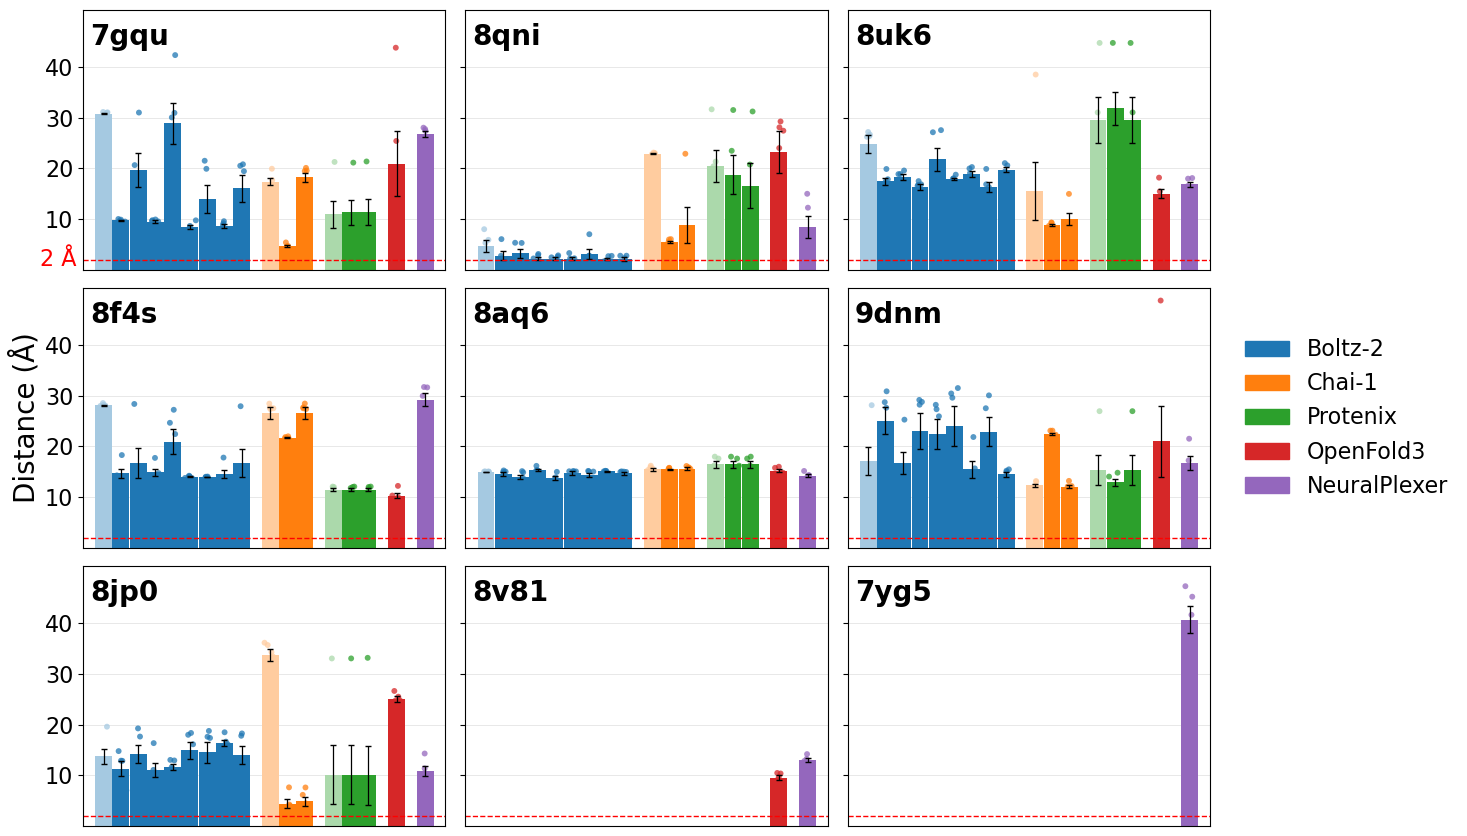

In [83]:
# Build barplot grid per PDB using the `results` DataFrame
# - Groups specific cof values under top-level cof names (e.g. any name containing 'boltz' grouped under 'boltz')
# - Bars correspond to combinations of specific cof and restr_dist; NaN restr_dist bars are lighter version of the group's color
# - Errorbars show SEM; horizontal red line at y=2; shared axes across subplots
import math
import matplotlib as mpl
from matplotlib import colors as mcolors
import matplotlib.patches as mpatches

# ----- User-tweakable parameters -----
font_scale = 2         # multiply to increase/decrease text sizes
figsize_scale = 1.0       # multiply to increase/decrease the whole figure size
save_svg = True
svg_filename = 'cof_grid.svg'
# how much lighter the no-restr bar should be (0 -> same color, 1 -> white)
lightness_no_restr = 0.6
# spacing control
intra_group_gap = 0.0    # minimal gap between specific COFs within the same top-level group
inter_group_gap = 0.6    # larger gap between top-level groups

jitter_fraction = 0.05   # fraction of bar_unit used for Gaussian jitter width
point_alpha = 1
point_size = 18
# ordering provided by user
cof_order = ['boltz', 'chai', 'protenix', 'openfold3', 'neuralplexer']
# Define PDB order and create figure
pdb_order = ['7gqu', '8qni', '8uk6', '8f4s', '8aq6', '9dnm', '8jp0', '8v81', '7yg5']

# choose y column that starts with 'pose_center_dist'
pose_cols = [c for c in results.columns if str(c).startswith('pose_center_dist')]
if not pose_cols:
    raise ValueError("No column starting with 'pose_center_dist' found in results")
y_col = pose_cols[0]

# Ensure columns we will use exist
for col in ['pdb', 'cof', 'restr_dist']:
    if col not in results.columns:
        raise ValueError(f"results missing expected column: {col}")

# helper to make a lighter color
def lighten_color(color, amount=0.5):
    # color can be name or rgb tuple
    rgb = np.array(mcolors.to_rgb(color))
    white = np.array([1.0, 1.0, 1.0])
    return tuple(rgb + (white - rgb) * amount)

# Build global list of specific cof names
all_cofs = list(results['cof'].astype(str).unique())
# preserve order but group by top-level cof_order (match by substring)
specifics_by_group = {}
all_specifics_ordered = []
specific_to_group = {}
for g in cof_order:
    specifics = [c for c in all_cofs if g in c]
    specifics_by_group[g] = specifics
    for s in specifics:
        specific_to_group[s] = g
    all_specifics_ordered.extend(specifics)

# For each specific cof, determine restr_dist categories (NaN first)
restrs_by_specific = {}
for specific in all_specifics_ordered:
    vals = results.loc[results['cof'] == specific, 'restr_dist'].unique()
    nan_vals = [v for v in vals if pd.isna(v)]
    other_vals = sorted([v for v in vals if not pd.isna(v)])
    restrs_by_specific[specific] = nan_vals + other_vals

# Build global bar/box sequence (x positions) and keep mapping to (specific, restr)
global_bar_specs = []
x_positions = []
centers = []
labels_for_centers = []
pos = 0.0
bar_unit = 0.9           # reduced allocation per bar so bars are more tightly packed

for g_idx, g in enumerate(cof_order):
    specifics = specifics_by_group.get(g, [])
    for s_idx, specific in enumerate(specifics):
        restrs = restrs_by_specific.get(specific, [])
        if len(restrs) == 0:
            pos += intra_group_gap
            continue
        start = pos
        for r in restrs:
            x_positions.append(pos)
            global_bar_specs.append((specific, r))
            pos += bar_unit
        k = len(restrs)
        center = start + (k - 1) / 2.0 * bar_unit
        centers.append(center)
        labels_for_centers.append(specific)
        # choose gap after this specific: intra_group_gap unless it's the last specific in this group
        if s_idx < len(specifics) - 1:
            pos += intra_group_gap
    # after each top-level group, add inter_group_gap
    pos += inter_group_gap

total_x = pos

# Compute group centers for top-level x-axis labels (one label per group in cof_order)
group_centers = []
for g in cof_order:
    specs = specifics_by_group.get(g, [])
    idxs = [labels_for_centers.index(s) for s in specs if s in labels_for_centers]
    if not idxs:
        group_centers.append(None)
        continue
    vals = [centers[i] for i in idxs]
    group_centers.append(sum(vals) / len(vals))

# Color mapping: one color per top-level cof group; no black bars anymore
n_groups = len(cof_order)
palette = sns.color_palette(n_colors=max(1, n_groups))
group_color_map = {g: palette[i % len(palette)] for i, g in enumerate(cof_order)}

# Figure layout and sizing
nplots = len(pdb_order)
ncols = 3
nrows = math.ceil(nplots / ncols)
base_w, base_h = 5.0, 3.0
fig_w = ncols * base_w * figsize_scale
fig_h = nrows * base_h * figsize_scale
fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), sharey=True, sharex=True)
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
else:
    axes = [axes]

# Add subtle horizontal grid lines on y-axis ticks and place grid behind bars
for ax in axes:
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color='gray', linestyle='-', linewidth=0.5, alpha=0.25)

# Base font sizes
base_title_fs = 10 * font_scale
base_tick_fs = 8 * font_scale
base_label_fs = 10 * font_scale

# mapping for legend display names
display_names = {
    'boltz': 'Boltz-2',
    'chai': 'Chai-1',
    'protenix': 'Protenix',
    'openfold3': 'OpenFold3',
    'neuralplexer': 'NeuralPlexer'
}

# Plot each pdb in order
for idx, pdb in enumerate(pdb_order):
    ax = axes[idx]
    # place title inside the box (top-left)
    ax.text(0.02, 0.95, str(pdb), transform=ax.transAxes, ha='left', va='top', fontsize=base_tick_fs, fontweight='bold')

    # For each global bar/box slot, compute values for this pdb+specific+restr
    for x, (specific, restr) in zip(x_positions, global_bar_specs):
        sub = results[(results['pdb'] == pdb) & (results['cof'] == specific)]
        if pd.isna(restr):
            mask = sub['restr_dist'].isna()
        else:
            mask = sub['restr_dist'] == restr
        vals = sub.loc[mask, y_col]
        if vals.empty:
            continue
        # color selection matches previous logic: base color per top-level group; lighter if restr is NaN
        group = specific_to_group.get(specific, '')
        base_col = group_color_map.get(group, 'gray')
        if pd.isna(restr):
            if group in ['openfold3', 'neuralplexer']:
                color = base_col
            else:
                color = lighten_color(base_col, amount=lightness_no_restr)
        else:
            color = base_col

        # Plot jittered points (individual datapoints) so viewers see distribution; keep alpha lower than box face
        npts = len(vals)
        if npts > 0:
            rng = np.random.default_rng(seed=None)
            jitter_width = bar_unit * jitter_fraction
            jitter = rng.normal(loc=0.0, scale=jitter_width, size=npts)
            jittered_x = np.full(npts, x) + jitter
            # draw jittered points behind boxplots by using a low zorder
            ax.scatter(jittered_x, vals, color=color, s=point_size, alpha=point_alpha, edgecolors='none', zorder=1)

        # # Draw boxplot at this x position: outline-only (no fill) with colored outline and whiskers/median
        # bp = ax.boxplot(vals.values, positions=[x], widths=bar_unit * 0.9, patch_artist=True,
        #                 boxprops=dict(facecolor='none', color=color, linewidth=1),
        #                 whiskerprops=dict(color=color, linewidth=1.0),
        #                 capprops=dict(color=color, linewidth=1.0),
        #                 medianprops=dict(color=color, linewidth=1),
        #                 flierprops=dict(marker='o', markersize=3, alpha=0.0))
        # # Ensure boxplot artists are drawn above the jittered points so outlines remain visible
        # for key in ['boxes', 'whiskers', 'caps', 'medians', 'fliers']:
        #     for artist in bp.get(key, []):
        #         try:
        #             artist.set_zorder(4)
        #         except Exception:
        #             pass
        # # Make sure the boxes have no facecolor and use the group color for the edge
        # for b in bp.get('boxes', []):
        #     try:
        #         b.set_facecolor('none')
        #         b.set_edgecolor(color)
        #         b.set_linewidth(1.2)
        #     except Exception:
        #         pass

    # horizontal red line at y=2
    ax.axhline(2, color='red', linestyle='--', linewidth=1)

    # For the top-left plot, add an external label left of the red line in red color
    if idx == 0:
        ax.text(-bar_unit * 1.6, 2, '2 Å', color='red', fontsize=base_tick_fs, va='center', ha='right', clip_on=False)

    ax.set_xlim(-bar_unit * 1.2, total_x - bar_unit * 0.5)

    # Remove individual x-axis ticks/labels (we will use a color legend instead)
    ax.set_xticks([])
    ax.set_xticklabels([])

    # Only show y ticks on left column plots, set them explicitly to 10,20,30,40 (hide 0)
    col = idx % ncols
    if col == 0:
        yticks = [0, 10, 20, 30, 40]
        ax.set_ylim(0, 41)
        ymin, ymax = ax.get_ylim()
        if ymax < max(yticks):
            ax.set_ylim(ymin, max(yticks) + 2)
        ax.set_yticks(yticks)
        ax.set_yticklabels( [str(t) if t != 0 else '' for t in yticks], fontsize=base_tick_fs)
        ax.tick_params(axis='y', which='both', labelsize=base_tick_fs)

# Remove any extra empty axes
for j in range(nplots, nrows * ncols):
    fig.delaxes(axes[j])

# Shared y-axis label for the whole figure (angstrom symbol included)
fig.text(0.04, 0.5, 'Distance (Å)', va='center', rotation='vertical', fontsize=base_label_fs)

# Create legend handles using the DEFAULT full hue version of each group's color and beautified names
legend_handles = []
for g in cof_order:
    base_col = group_color_map.get(g)
    patch = mpatches.Patch(color=base_col, label=display_names.get(g, g))
    legend_handles.append(patch)

# Place legend to the right of the grid
plt.tight_layout(rect=[0.05, 0.03, 0.85, 0.97])
fig.legend(handles=legend_handles, loc='center left', bbox_to_anchor=(0.85, 0.5), frameon=False, fontsize=base_tick_fs)

# Save the figure if requested
if save_svg:
    fig.savefig("Desktop/AlloPockets/ensembles/cofolding/cof_grid.svg", transparent=True, bbox_inches='tight')

plt.show()


## Old plots

# Full guidance